# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   Dataset yang digunakan pada proyek ini diperoleh dari platform kaggle dengan nama synthetic diabetes prediction dataset
   
   link: https://www.kaggle.com/datasets/miadul/synthetic-diabetes-prediction-dataset


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,id,age,gender,bmi,glucose,blood_pressure,cholesterol,heart_rate,sleep_hours,physical_activity,smoking,alcohol_intake,family_history,stress_level,diet_score,steps_per_day,work_hours,water_intake_ltr,insulin,diabetes
0,1,69,Male,23.30,170,137,139,66,6.4,High,1,1,1,8,3,8760,6,3.6,33,0
1,2,32,Male,25.00,184,177,250,75,6.4,Medium,0,1,1,4,7,7682,11,4.1,36,0
2,3,89,Female,28.57,87,164,225,102,7.5,Medium,1,0,0,6,5,15025,8,1.4,46,1
3,4,78,Male,15.85,96,113,158,112,6.9,Low,0,1,1,2,7,4645,4,4.4,171,1
4,5,38,Female,35.74,171,122,193,109,7.4,Medium,0,1,0,6,9,7862,13,3.9,235,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (10000, 20)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   age                10000 non-null  int64  
 2   gender             10000 non-null  object 
 3   bmi                10000 non-null  float64
 4   glucose            10000 non-null  int64  
 5   blood_pressure     10000 non-null  int64  
 6   cholesterol        10000 non-null  int64  
 7   heart_rate         10000 non-null  int64  
 8   sleep_hours        10000 non-null  float64
 9   physical_activity  10000 non-null  object 
 10  smoking            10000 non-null  int64  
 11  alcohol_intake     10000 non-null  int64  
 12  family_history     10000 non-null  int64  
 13  stress_level       10000 non-null  int64  
 14  diet_score         10000 non-null  int64  
 15  steps_per_day      10000 non-null  int64  
 16  work_hours         1000

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.500000,2886.895680,1.00,2500.75,5000.500,7500.25,10000.00
age,10000.0,53.539700,20.757324,18.00,36.00,53.000,72.00,89.00
bmi,10000.0,24.986252,4.900648,7.55,21.63,24.935,28.29,41.59
glucose,10000.0,133.973400,37.648549,70.00,101.00,134.000,167.00,199.00
blood_pressure,10000.0,129.483500,29.044113,80.00,104.00,129.000,155.00,179.00
cholesterol,10000.0,209.343200,52.140223,120.00,164.00,210.000,255.00,299.00
heart_rate,10000.0,89.696100,17.138626,60.00,75.00,90.000,104.00,119.00
sleep_hours,10000.0,6.530970,2.033643,3.00,4.80,6.500,8.30,10.00
smoking,10000.0,0.496400,0.500012,0.00,0.00,0.000,1.00,1.00
alcohol_intake,10000.0,0.503700,0.500011,0.00,0.00,1.000,1.00,1.00


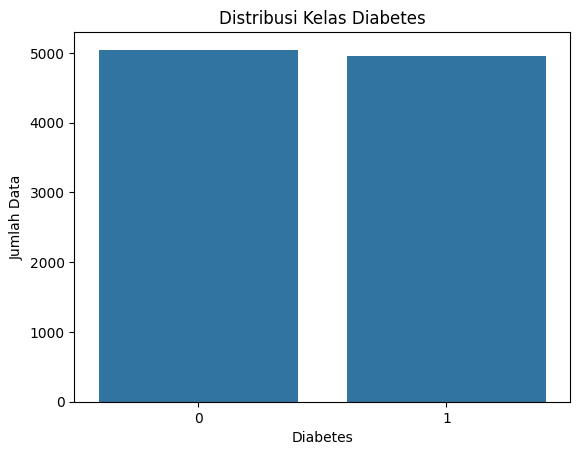

In [7]:
# distribusi kolom target (x) = diabetes
sns.countplot(x='diabetes', data=df)
plt.title('Distribusi Kelas Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Jumlah Data')
plt.show()

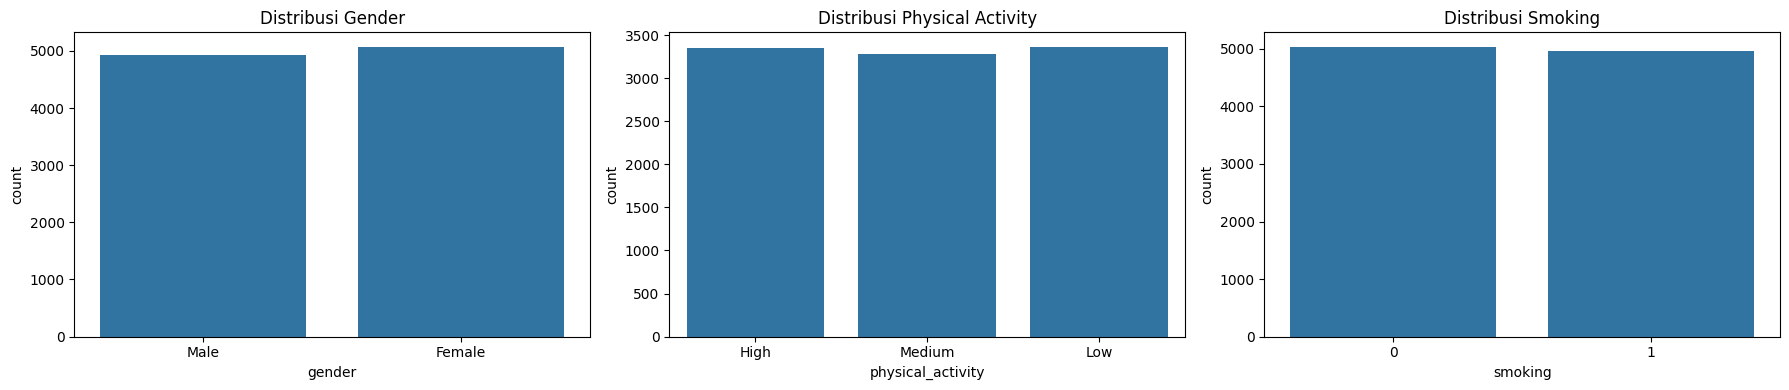

In [8]:
# analisis fitur kategorikal (gender, physical_activity,  dan smoking)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(x='gender', data=df, ax=ax[0])
ax[0].set_title('Distribusi Gender')

sns.countplot(x='physical_activity', data=df, ax=ax[1])
ax[1].set_title('Distribusi Physical Activity')

sns.countplot(x='smoking', data=df, ax=ax[2])
ax[2].set_title('Distribusi Smoking')

plt.tight_layout()
plt.show()

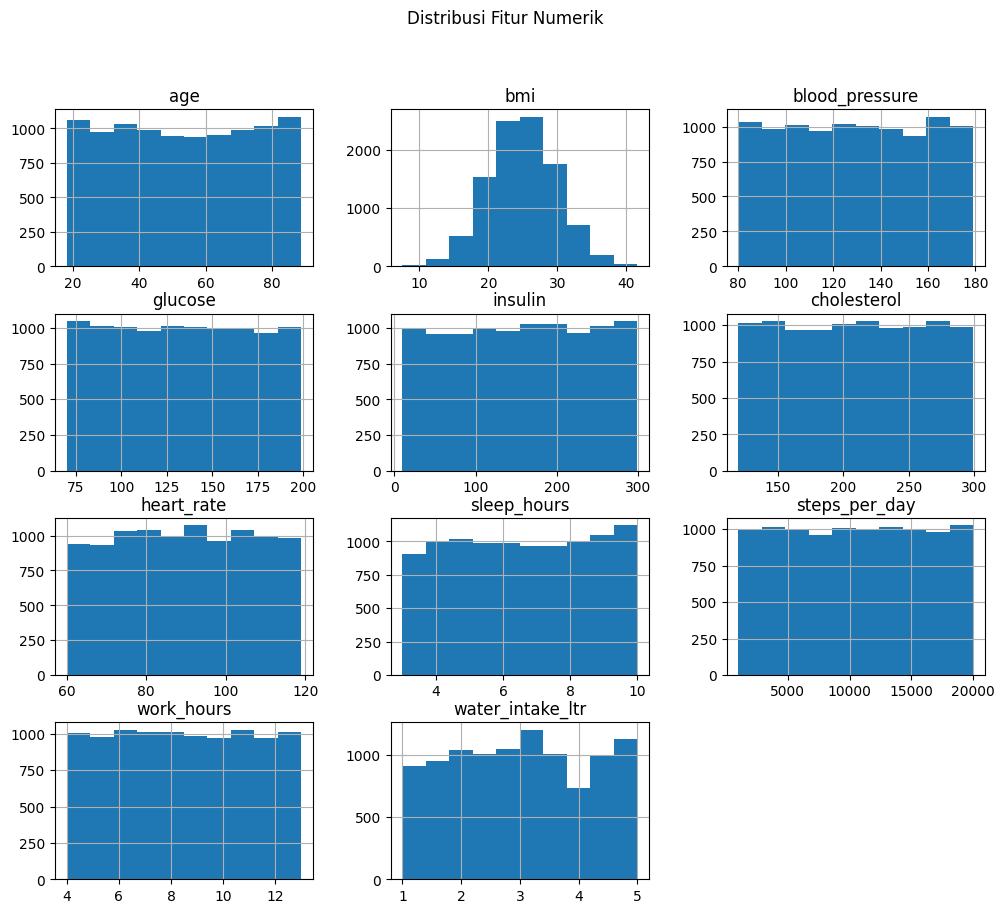

In [9]:
# analisis fitur numerik
numerical_features = [
    'age', 'bmi', 'blood_pressure', 'glucose',
    'insulin', 'cholesterol', 'heart_rate',
    'sleep_hours', 'steps_per_day', 'work_hours',
    'water_intake_ltr'
]

df[numerical_features].hist(figsize=(12, 10))
plt.suptitle('Distribusi Fitur Numerik')
plt.show()

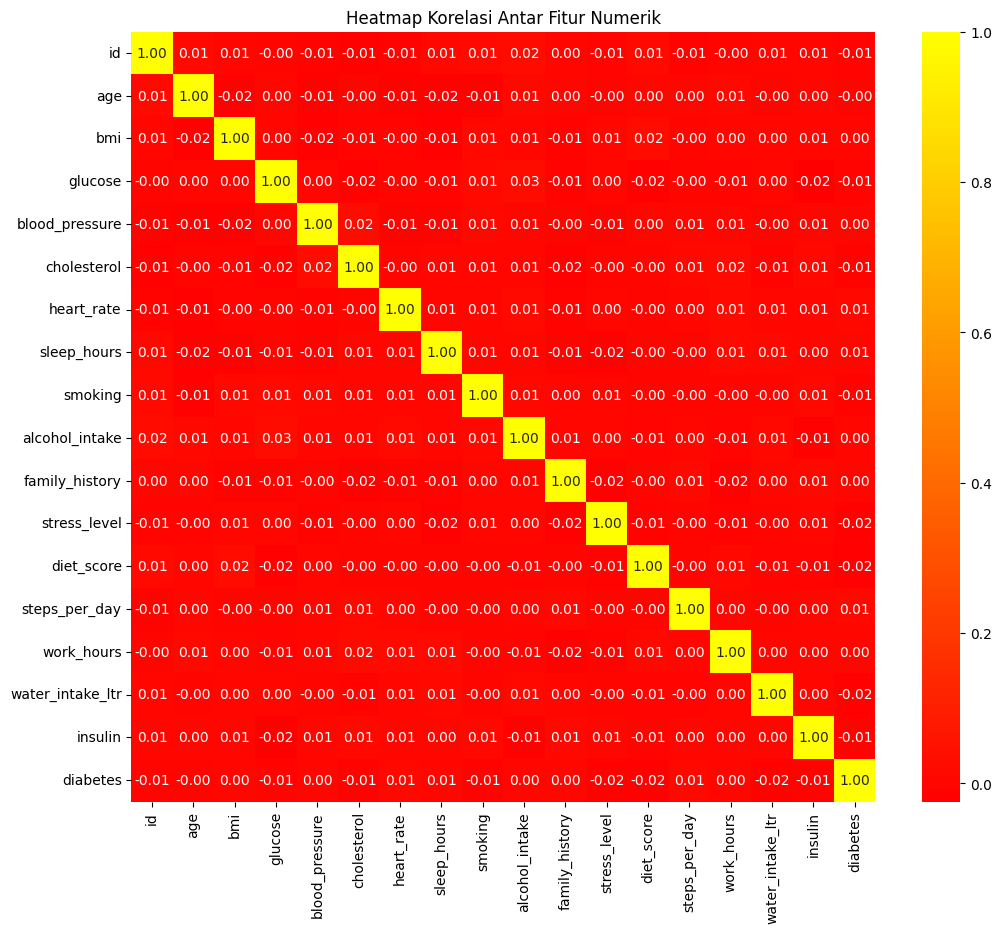

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='autumn',
    fmt=".2f"
)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
# mengecek missing value
df.isnull().sum()

,0
id,0
age,0
gender,0
bmi,0
glucose,0
blood_pressure,0
cholesterol,0
heart_rate,0
sleep_hours,0
physical_activity,0


In [12]:
# mengecek data duplikat
df.duplicated().sum()

np.int64(0)

In [13]:
# pemisahan fitur dan target
X = df.drop(columns=['diabetes'])
y = df['diabetes']

In [14]:
# hapus kolom tidak relevan
X = X.drop(columns=['id'])

In [15]:
# definisi tipe fitur
categorical_features = ['gender', 'physical_activity']

numeric_features = [
    'age', 'bmi', 'blood_pressure', 'glucose',
    'cholesterol', 'heart_rate', 'sleep_hours',
    'smoking', 'alcohol_intake', 'family_history',
    'stress_level', 'diet_score', 'steps_per_day',
    'work_hours', 'water_intake_ltr', 'insulin'
]

In [17]:
X.head()

,age,gender,bmi,glucose,blood_pressure,cholesterol,heart_rate,sleep_hours,physical_activity,smoking,alcohol_intake,family_history,stress_level,diet_score,steps_per_day,work_hours,water_intake_ltr,insulin
0,69,Male,23.30,170,137,139,66,6.4,High,1,1,1,8,3,8760,6,3.6,33
1,32,Male,25.00,184,177,250,75,6.4,Medium,0,1,1,4,7,7682,11,4.1,36
2,89,Female,28.57,87,164,225,102,7.5,Medium,1,0,0,6,5,15025,8,1.4,46
3,78,Male,15.85,96,113,158,112,6.9,Low,0,1,1,2,7,4645,4,4.4,171
4,38,Female,35.74,171,122,193,109,7.4,Medium,0,1,0,6,9,7862,13,3.9,235


In [19]:
# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [20]:
# simpan hasil processing ke CSV
feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [21]:
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [22]:
train_processed = X_train_df.copy()
train_processed['diabetes'] = y_train.values

test_processed = X_test_df.copy()
test_processed['diabetes'] = y_test.values

In [23]:
train_processed.to_csv('diabetes_train.csv', index=False)
test_processed.to_csv('diabetes_test.csv', index=False)

In [24]:
# simpan aturan preprocessing
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']